# One-observation verification pipeline

This notebook runs a minimal workflow on a single parcel observation from the shapefile:
1. find the observation date and snap it to the nearest Sentinel-2 date,
2. extract a small parcel patch,
3. run a simple super-resolution step,
4. create LR/SR parcel masks,
5. save the outputs and display them.

Device: cpu
Loading SEN2SRLite...


100%|██████████| 9/9 [00:42<00:00,  4.72s/it]


SR output shape: (10, 1024, 1024)
LR patch shape : (10, 256, 256)
SR patch shape : (10, 1024, 1024)
Mask shape     : (1024, 1024)

 id_plot observation_column observation_date s2_acquisition_date  yellowness lr_patch_path sr_patch_path lr_mask_path sr_mask_path  NDRE_mean  NDRE_std  NDYVI_mean  NDYVI_std  GCC_mean  GCC_std  NDYI_mean  NDYI_std  mNDblue_mean  mNDblue_std
10597132              17_11       2020-11-17          2020-11-16        10.0  lr_patch.tif  sr_patch.tif  lr_mask.tif  sr_mask.tif   0.146343  0.025077   -0.168248   0.027702  0.333877 0.004713   0.166606  0.013974     -0.376767     0.029035

Saved outputs to: C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\notebooks\verification_outputs


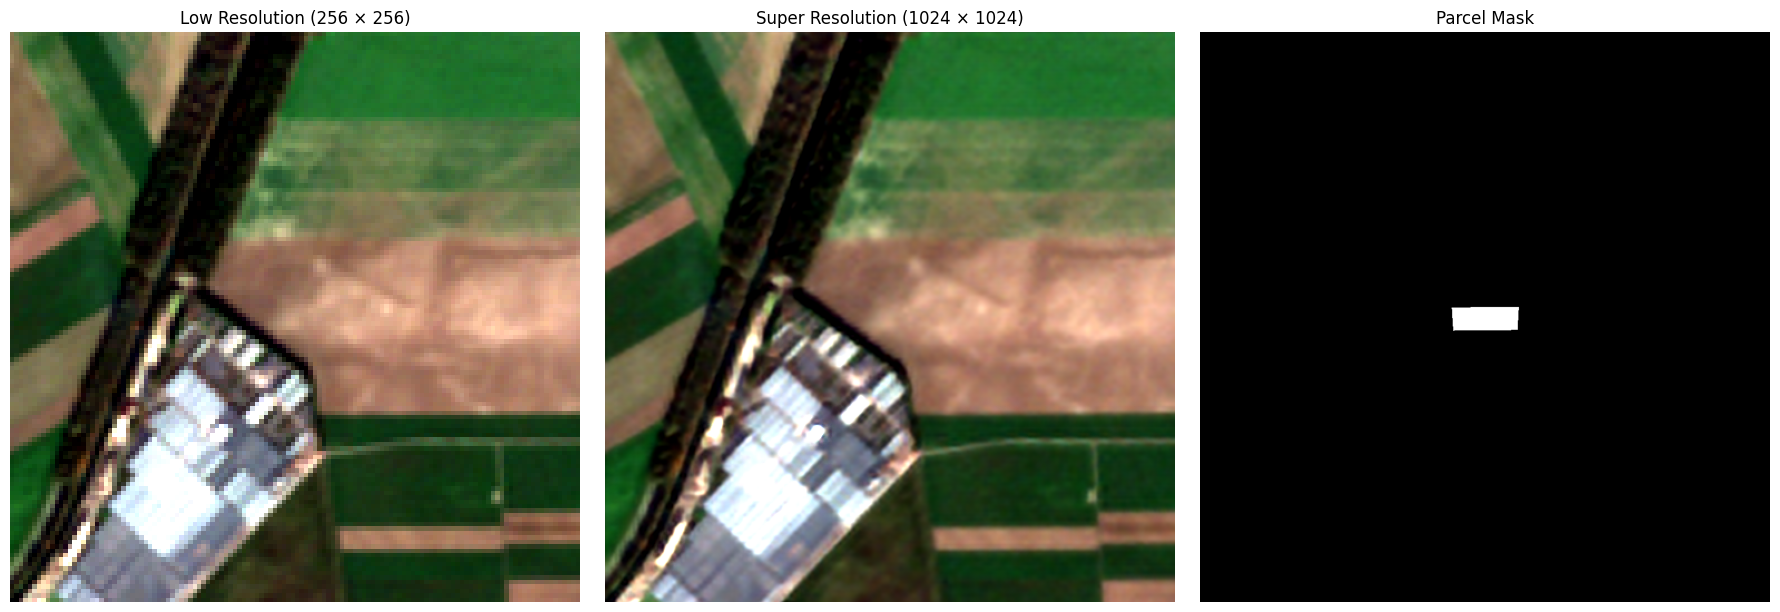

In [ ]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import mlstac
import numpy as np
import pandas as pd
import rasterio
import sen2sr
import torch
from rasterio.transform import Affine
from shapely.geometry import box

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from s2_pipeline import (
    ParcelMaskGenerator,
    ParcelPatchExtractor,
    SpectralIndexComputer,
    TemporalDateMatcher,
)

# --- configure paths ---
stack_path = Path(r"C:/Users/ahtrabelsi/Desktop/stage/S2 data/Sentinel2_T31UEQ_TSG.tif")
parcels_path = repo_root / "data" / "2020_buf20" / "2020_buf20.shp"
calendar_path = repo_root / "data" / "Sentinel2_T31UEQ_interpolation_dates.txt"
out_dir = repo_root / "notebooks" / "verification_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

# --- load inputs ---
matcher = TemporalDateMatcher(calendar_path)
gdf = gpd.read_file(parcels_path)

with rasterio.open(stack_path) as src:
    parcels = gdf.to_crs(src.crs)
    parcels = parcels[parcels.intersects(box(*src.bounds))].reset_index(drop=True)
    crs = src.crs
    raster_transform = src.transform

# --- pick the first parcel and first valid observation column ---
parcel_row = parcels.iloc[0]
observation_columns = [col for col in parcels.columns if "12_05" <= col <= "18_11"]
observation_column = None
for col in observation_columns:
    value = parcel_row.get(col)
    if pd.notna(value) and float(value) != 0:
        observation_column = col
        break
if observation_column is None:
    raise ValueError("No non-zero observation values found in the first parcel")

obs_date = TemporalDateMatcher.parse_observation_column(observation_column)
s2_date_str = matcher.find_nearest_s2_date(obs_date)
band_offset = matcher.get_band_offset(s2_date_str)

# --- extract a parcel-centered patch ---
patch_extractor = ParcelPatchExtractor(min_patch_size=256)
window = patch_extractor.compute_window(
    geom=parcel_row.geometry,
    img_height=src.height,
    img_width=src.width,
    raster_transform=raster_transform,
    parcel_index=0,
)
if window is None:
    raise RuntimeError("Patch window fell outside the raster bounds")

band_start = band_offset * 10 + 1
band_indexes = list(range(band_start, band_start + 10))
with rasterio.open(stack_path) as src:
    lr_patch = src.read(
        band_indexes,
        window=rasterio.windows.Window(
            col_off=window.col_min,
            row_off=window.row_min,
            width=window.col_max - window.col_min,
            height=window.row_max - window.row_min,
        ),
    )

# --- normalize the LR cube before SR and saving ---
normalized_lr_patch = lr_patch.astype(np.float32) / 10000.0
normalized_lr_patch = np.clip(normalized_lr_patch, 0.0, 1.0)

# --- load the SEN2SR model and run SR on a large patch ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def load_sr_model(model_url: str, output_dir: Path, device: torch.device):
    mlstac.download(file=model_url, output_dir=str(output_dir))
    model = mlstac.load(str(output_dir)).compiled_model(device=device)
    model.eval()
    return model


def is_model_compatible(height: int, width: int) -> bool:
    return height >= 128 and width >= 128


def bicubic_upsample(cube: np.ndarray, upscale: int = 4) -> np.ndarray:
    tensor = torch.from_numpy(cube).float()
    tensor = tensor.unsqueeze(0)
    upsampled = torch.nn.functional.interpolate(
        tensor,
        scale_factor=upscale,
        mode="bicubic",
        align_corners=False,
    )
    return upsampled.squeeze(0).cpu().numpy()


MODEL_URL = "https://huggingface.co/tacofoundation/sen2sr/resolve/main/SEN2SRLite/main/mlm.json"
MODEL_DIR = repo_root / "model" / "SEN2SRLite"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OVERLAP = 32
UPSCALE = 4

print("Loading SEN2SRLite...")
SEN2SRLite = load_sr_model(MODEL_URL, MODEL_DIR, device)

cube = normalized_lr_patch.astype(np.float32)
cube = np.nan_to_num(cube)
H, W = cube.shape[1:]

if is_model_compatible(H, W):
    X = torch.from_numpy(cube).to(device)
    with torch.no_grad():
        sr_cube = sen2sr.predict_large(
            model=SEN2SRLite,
            X=X,
            overlap=OVERLAP,
        )
    if isinstance(sr_cube, torch.Tensor):
        sr_cube = sr_cube.cpu().numpy()
else:
    sr_cube = bicubic_upsample(cube, UPSCALE)

sr_cube = np.clip(sr_cube.astype(np.float32), 0.0, 1.0)
print("SR output shape:", sr_cube.shape)

# --- create masks ---
zone_bounds = window.zone.bounds
lr_mask, sr_mask, lr_transform, sr_transform = ParcelMaskGenerator.create_masks(
    parcel_geometry=parcel_row.geometry,
    zone_bounds=zone_bounds,
    lr_shape=(normalized_lr_patch.shape[1], normalized_lr_patch.shape[2]),
    sr_shape=(sr_cube.shape[1], sr_cube.shape[2]),
)

# --- compute parcel-only spectral statistics ---
indexer = SpectralIndexComputer()
index_stats = indexer.compute_stats(normalized_lr_patch.astype(np.float32), lr_mask)

# --- save outputs ---
def write_geotiff(path: Path, array: np.ndarray, height: int, width: int, count: int, transform: Affine) -> None:
    with rasterio.open(
        path,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=count,
        dtype=array.dtype,
        crs=crs,
        transform=transform,
    ) as dst:
        if array.ndim == 2:
            dst.write(array.astype(np.float32), 1)
        else:
            dst.write(array)

write_geotiff(
    out_dir / "lr_patch.tif",
    normalized_lr_patch.astype(np.float32),
    normalized_lr_patch.shape[1],
    normalized_lr_patch.shape[2],
    normalized_lr_patch.shape[0],
    lr_transform,
)
write_geotiff(
    out_dir / "sr_patch.tif",
    sr_cube.astype(np.float32),
    sr_cube.shape[1],
    sr_cube.shape[2],
    sr_cube.shape[0],
    sr_transform,
)
write_geotiff(out_dir / "lr_mask.tif", lr_mask.astype(np.uint8), lr_mask.shape[0], lr_mask.shape[1], 1, lr_transform)
write_geotiff(out_dir / "sr_mask.tif", sr_mask.astype(np.uint8), sr_mask.shape[0], sr_mask.shape[1], 1, sr_transform)

inventory = pd.DataFrame([
    {
        "id_plot": parcel_row.get("ID_PARCEL", 0),
        "observation_column": observation_column,
        "observation_date": obs_date.isoformat(),
        "s2_acquisition_date": s2_date_str,
        "yellowness": float(parcel_row.get(observation_column, np.nan)),
        "lr_patch_path": "lr_patch.tif",
        "sr_patch_path": "sr_patch.tif",
        "lr_mask_path": "lr_mask.tif",
        "sr_mask_path": "sr_mask.tif",
        **index_stats,
    }
])
inventory.to_csv(out_dir / "single_observation_inventory.csv", index=False)

# --- display outputs with percentile stretch ---
def percentile_stretch(image: np.ndarray, low: float = 2.0, high: float = 98.0) -> np.ndarray:
    image = np.asarray(image, dtype=np.float32)

    if image.size == 0:
        return image

    if image.ndim == 3:
        stretched = np.empty_like(image)
        for band in range(image.shape[2]):
            band_values = image[:, :, band]

            if band_values.size == 0:
                stretched[:, :, band] = 0
                continue

            lo, hi = np.percentile(band_values, [low, high])

            if hi > lo:
                stretched[:, :, band] = np.clip((band_values - lo) / (hi - lo), 0.0, 1.0)
            else:
                stretched[:, :, band] = 0.0

        return stretched

    lo, hi = np.percentile(image, [low, high])

    if hi > lo:
        return np.clip((image - lo) / (hi - lo), 0.0, 1.0)

    return np.zeros_like(image)


# ------------------------------------------------------------------
# Use the full images (no cropping)
# ------------------------------------------------------------------
lr_vis = normalized_lr_patch
sr_vis = sr_cube
mask_vis = sr_mask[0] if sr_mask.ndim == 3 else sr_mask

print("LR patch shape :", lr_vis.shape)
print("SR patch shape :", sr_vis.shape)
print("Mask shape     :", mask_vis.shape)

# RGB visualization (Sentinel-2: B4,B3,B2 -> bands 2,1,0)
rgb_lr = np.moveaxis(lr_vis[[2, 1, 0]], 0, -1)
rgb_lr = percentile_stretch(rgb_lr)

rgb_sr = np.moveaxis(sr_vis[[2, 1, 0]], 0, -1)
rgb_sr = percentile_stretch(rgb_sr)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb_lr[:128, :128])
axes[0].set_title(f"Low Resolution ({lr_vis.shape[2]} × {lr_vis.shape[1]})")
axes[0].axis("off")

axes[1].imshow(rgb_sr[:512, :512])
axes[1].set_title(f"Super Resolution ({sr_vis.shape[2]} × {sr_vis.shape[1]})")
axes[1].axis("off")

axes[2].imshow(mask_vis, cmap="gray")
axes[2].set_title("Parcel Mask")
axes[2].axis("off")

print()
print(inventory.to_string(index=False))
print()
print("Saved outputs to:", out_dir)

plt.tight_layout()
plt.show()